# Implementing a ground-motion model

**Geotechnical Hazards** · tutorial for Lecture 9

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pstafford/geohazards-psha/blob/main/notebooks/03_implement_a_gmm.ipynb)

The best way to understand a ground-motion model (GMM) is to implement one: turn the published
equation and coefficient table into code, and check that it gives the same numbers as somebody
else's implementation. This notebook does that for **Akkar & Bommer (2010)**, then sets a harder
challenge: the reference-rock part of **Chiou & Youngs (2014)**.

Run the cells in order (Shift + Enter). Cells marked ✏️ are for you to write or change.

In [1]:
# Setup. On Colab this downloads the course code; on your own computer it uses the repository.
import os, sys, subprocess
if "google.colab" in sys.modules:
    if not os.path.exists("geohazards-psha"):
        subprocess.run(["git", "clone", "-q", "https://github.com/pstafford/geohazards-psha"], check=True)
    sys.path.insert(0, "geohazards-psha/psha")
else:
    sys.path.insert(0, os.path.abspath("../psha"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psha_toy as pt

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 12})
FAULT_C, AREA_C = "#D24000", "#0000CD"     # the colours used in the lectures
P = pt.PARAMS                               # the model's parameters

## 1. The model

Akkar & Bommer (2010) predict the 5 %-damped pseudo-spectral acceleration $PSA$ (in cm/s²) of the
geometric mean of the two horizontal components:

$$\log_{10} PSA = b_1 + b_2 M + b_3 M^2 + (b_4 + b_5 M)\log_{10}\sqrt{R_{JB}^2 + b_6^2} + b_7 S_S + b_8 S_A + b_9 F_N + b_{10} F_R$$

* $M$: moment magnitude; $R_{JB}$: Joyner–Boore distance (km), the shortest distance to the surface projection of the rupture
* $S_S = 1$ for soft soil ($V_{S30} < 360$ m/s), $S_A = 1$ for stiff soil ($360 \leq V_{S30} \leq 750$ m/s), both 0 for rock
* $F_N = 1$ for normal faulting (rake between −135° and −45°), $F_R = 1$ for reverse faulting (rake between 45° and 135°)
* the standard deviations are given in $\log_{10}$ units: $\sigma_1$ (within-event), $\sigma_2$ (between-event, called `tau` here) and their combination `SigmaTot`

## 2. The coefficients

One row per period (0 is PGA), as in Table 1 of the paper:

In [2]:
here = sys.path[0]                          # the folder with the course's code and data
coeffs = pd.read_csv(os.path.join(here, "ab10_coefficients.csv"), comment="#", index_col="period")
coeffs.loc[[0, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0]]

,b1,b2,b3,b4,b5,b6,b7,b8,b9,b10,Sigma1,tau,SigmaTot
period,,,,,,,,,,,,,
0.0,1.43525,0.74866,-0.06520,-2.72950,0.25139,7.74959,0.08320,0.00766,-0.05823,0.07087,0.2611,0.1056,0.281646
0.1,2.11994,0.75179,-0.07448,-3.10538,0.30253,8.21405,0.02667,-0.00062,-0.04906,0.07910,0.2728,0.1167,0.296713
0.2,0.92065,0.96815,-0.07903,-2.49264,0.21790,8.21914,0.06557,0.02105,-0.02098,0.08438,0.2821,0.1081,0.302103
0.5,-2.76925,1.83268,-0.13202,-2.12969,0.16877,7.17423,0.25944,0.13562,-0.04283,0.08579,0.3078,0.1163,0.329039
1.0,-6.17066,2.58558,-0.17938,-1.80717,0.13599,4.97596,0.36619,0.19519,-0.02269,0.02121,0.2895,0.1483,0.325274
2.0,-7.50404,2.71004,-0.17130,-1.44395,0.06602,7.26059,0.33298,0.15839,-0.02258,-0.00486,0.2835,0.1657,0.328373
3.0,-6.92924,2.45899,-0.15513,-1.76801,0.13314,7.21950,0.29772,0.13198,-0.03855,-0.02469,0.2876,0.1785,0.338491


## 3. Write it yourself ✏️

Complete the function below: it takes the row of coefficients for one period and returns the median
in **g** and the standard deviation in **natural-log** units. Try it before you look at section 4.

In [3]:
def my_ab10(c, mag, rjb, vs30, rake):
    """c: one row of `coeffs`, e.g. coeffs.loc[1.0]. Returns (median in g, sigma in ln units)."""
    # ✏️ your code here
    raise NotImplementedError("write the equation of section 1")

## 4. One possible answer

In [4]:
def ab10(c, mag, rjb, vs30, rake):
    Ss, Sa = vs30 < 360, 360 <= vs30 <= 750                 # site classes (True = 1)
    Fn, Fr = -135 <= rake <= -45, 45 <= rake <= 135         # style of faulting
    log10_psa = (c["b1"] + c["b2"] * mag + c["b3"] * mag**2
                 + (c["b4"] + c["b5"] * mag) * np.log10(np.sqrt(rjb**2 + c["b6"]**2))
                 + c["b7"] * Ss + c["b8"] * Sa + c["b9"] * Fn + c["b10"] * Fr)
    median = 10**log10_psa / 981.0                          # cm/s^2 to g
    sigma = c["SigmaTot"] * np.log(10)                      # log10 units to natural-log units
    return median, sigma

ab10(coeffs.loc[1.0], 6.5, 20, 400, 0)

(np.float64(0.11146251158087818), np.float64(0.7489710635385453))

## 5. Check it

`ab10_check.csv` holds OpenQuake's predictions (its `AkkarBommer2010`) for random scenarios.
Compare yours: if your function works, change `model = ab10` to `model = my_ab10`.

In [5]:
model = ab10                                # ✏️ my_ab10
check = pd.read_csv(os.path.join(here, "ab10_check.csv"), comment="#")
mine = [model(coeffs.loc[r.period], r.mag, r.rjb, r.vs30, r.rake) for r in check.itertuples()]
check["mine_g"] = [m for m, s in mine]
check["mine_sigma"] = [s for m, s in mine]
check["difference_%"] = 100 * (check["mine_g"] / check["median_g"] - 1)
display(check.round(4).head(10))
print(f"largest difference in the median: {check['difference_%'].abs().max():.3f} %; "
      f"in sigma: {(check['mine_sigma'] - check['sigma_ln']).abs().max():.1e}")

,period,mag,rjb,vs30,rake,median_g,sigma_ln,mine_g,mine_sigma,difference_%
0,2.0,5.62,40.0,250,-90,0.0081,0.7561,0.0081,0.7561,-0.0341
1,1.0,5.24,7.3,800,90,0.0280,0.7490,0.0279,0.7490,-0.0340
2,0.1,6.91,1.7,250,90,0.8617,0.6832,0.8614,0.6832,-0.0342
3,0.2,6.34,7.3,800,90,0.6578,0.6956,0.6576,0.6956,-0.0342
4,0.1,7.49,3.7,800,0,0.6020,0.6832,0.6018,0.6832,-0.0341
5,1.0,6.81,3.8,1200,0,0.2659,0.7490,0.2658,0.7490,-0.0342
6,0.0,5.78,4.2,1200,0,0.2434,0.6485,0.2433,0.6485,-0.0343
7,3.0,6.52,8.8,250,-90,0.0670,0.7794,0.0669,0.7794,-0.0341
8,0.5,6.84,5.6,250,0,0.8359,0.7576,0.8356,0.7576,-0.0342
9,0.0,6.72,72.9,1200,0,0.0389,0.6485,0.0389,0.6485,-0.0342


largest difference in the median: 0.034 %; in sigma: 8.6e-07


The medians differ by a constant 0.03 %. That is not a mistake in the equation: OpenQuake converts
cm/s² to g with the standard gravity, 980.665 cm/s², not 981. ✏️ Change it and run the check again.

Typical mistakes, which this kind of check catches immediately: $\log_{10}$ versus $\ln$ (in the
median *and* in $\sigma$), cm/s² versus g, the wrong distance metric, and the wrong definition of a
dummy variable.

## 6. Use it

With a working implementation, plots like those of the lecture take a few lines:

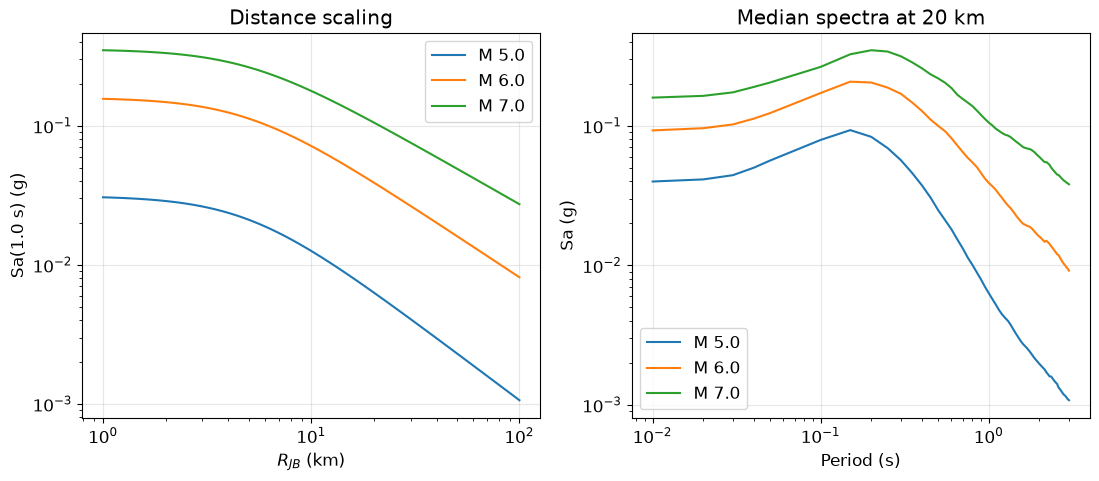

In [6]:
r = np.logspace(0, 2, 60)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
T = 1.0                                     # ✏️
for m in (5.0, 6.0, 7.0):
    a1.loglog(r, [ab10(coeffs.loc[T], m, x, 760, 0)[0] for x in r], label=f"M {m}")
a1.set(xlabel="$R_{JB}$ (km)", ylabel=f"Sa({T} s) (g)", title="Distance scaling")
a1.legend()
periods = coeffs.index[coeffs.index > 0]
for m in (5.0, 6.0, 7.0):
    a2.loglog(periods, [ab10(coeffs.loc[t], m, 20, 760, 0)[0] for t in periods], label=f"M {m}")
a2.set(xlabel="Period (s)", ylabel="Sa (g)", title="Median spectra at 20 km")
a2.legend();

### Periods between the tabulated ones

GMMs are defined only at the tabulated periods. In between, interpolate the **logarithm** of the
prediction linearly in the **logarithm** of the period:

In [7]:
def ab10_at(T, mag, rjb, vs30, rake):
    P = coeffs.index.values[coeffs.index.values > 0]
    if T in coeffs.index:
        return ab10(coeffs.loc[T], mag, rjb, vs30, rake)
    i = np.searchsorted(P, T)
    lo, hi = P[i - 1], P[i]
    (y0, s0), (y1, s1) = ab10(coeffs.loc[lo], mag, rjb, vs30, rake), ab10(coeffs.loc[hi], mag, rjb, vs30, rake)
    w = np.log(T / lo) / np.log(hi / lo)
    return np.exp((1 - w) * np.log(y0) + w * np.log(y1)), (1 - w) * s0 + w * s1

ab10_at(0.33, 6.5, 20, 760, 0)              # ✏️ any period between 0.05 and 3 s

(np.float64(0.2281258270818401), np.float64(0.7195108263522878))

## 7. A harder challenge: Chiou & Youngs (2014) on reference rock ✏️

The median of CY14 on its reference rock ($V_{S30}$ = 1130 m/s), for a vertical strike-slip
rupture whose top is at its average depth (so the style-of-faulting, dip and depth terms vanish),
and with no directivity or hanging-wall effects, is

$$
\ln y_{ref} = c_1 + c_2 (M - 6) + \frac{c_2 - c_3}{c_n}\ln\left(1 + e^{c_n (c_M - M)}\right)
+ c_4 \ln\left(R_{RUP} + c_5 \cosh\left(c_6 \max(M - c_{HM}, 0)\right)\right)
+ (c_{4a} - c_4)\ln\sqrt{R_{RUP}^2 + c_{RB}^2}
+ \left(c_{\gamma 1} + \frac{c_{\gamma 2}}{\cosh(\max(M - c_{\gamma 3}, 0))}\right) R_{RUP}
$$

with $c_2 = 1.06$, $c_4 = -2.1$, $c_{4a} = -0.5$ and $c_{RB} = 50$ km for every period; the other
coefficients are in `cy14_coefficients.csv` (columns `c1`, `c3`, `cn`, `cm`, `c5`, `c6`, `chm`,
`cg1`, `cg2`, `cg3`). Write it, and check it against `pt.cy14` (the version used in the PSHA
notebooks, itself checked against OpenQuake): at $V_{S30}$ = 1130 m/s the site terms are zero.

In [8]:
cy = pd.read_csv(os.path.join(here, "cy14_coefficients.csv"), comment="#", index_col="period")

def my_cy14_ref(c, mag, rrup):
    # ✏️ your code here: return ln y_ref
    raise NotImplementedError

def check_cy14(f):
    for T, m, r in ((0.0, 5.5, 10.0), (0.2, 6.5, 30.0), (1.0, 7.0, 50.0), (3.0, 7.8, 120.0)):
        z = max(2.673 - 1.136 * max(m - 4.970, 0), 0)**2          # average depth to the top of rupture
        rrup = np.hypot(r, z)
        ref = pt.cy14(T, np.array([m]), np.array([rrup]), np.array([r]), np.array([z]), 1130.0)[0][0]
        print(f"T={T} s, M {m}, Rjb {r} km: yours {f(cy.loc[T], m, rrup):.5f}, psha_toy {ref:.5f}")

try:
    check_cy14(my_cy14_ref)
except NotImplementedError:
    print("write my_cy14_ref first")

write my_cy14_ref first


If you get stuck, the same equation is implemented in `psha_toy.py` (function `cy14`), with the
site terms as well. Compare your code with it line by line.